# AI vs Human Text Detection — BERT Pipeline

Notebook ini menggunakan **`bert-base-cased`** untuk tokenisasi dan fine-tuning.

Struktur notebook:

| Bagian | Isi |
|---|---|
| **I** | Load data, balancing 50k/label, feature engineering (TextBlob + NLTK) |
| **II** | BERT Tokenisasi (BertTokenizer), Dataset HuggingFace |
| **III** | Fine-tuning `bert-base-cased` (BertForSequenceClassification + Trainer) |
| **IV** | Evaluasi (Accuracy, F1, Confusion Matrix, ROC Curve) |
| **V** | Save model & tokenizer (`save_pretrained`) + Demo inferensi |

> ⚠️ **Rekomendasi**: Jalankan di lingkungan dengan GPU (Kaggle / Google Colab).  
> Variabel `BERT_SAMPLE_SIZE` (Cell 12) dapat dikecilkan untuk tes cepat.

---
## ▶ BAGIAN I — Feature Engineering

### Cell 1 — Import Library

In [1]:
# ============================================================
# CELL 1: Import semua library
# ============================================================

import pandas as pd
import numpy as np
import string
import time
import os
import warnings
warnings.filterwarnings('ignore')
from multiprocessing import Pool, cpu_count

# HuggingFace
from datasets import load_dataset, concatenate_datasets, Dataset

# Transformers (BERT)
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import torch

# TextBlob & NLTK
from textblob import TextBlob
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Scikit-learn (evaluasi & utilities)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 80)

# Deteksi device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Library berhasil diimport.')
print(f'   Device     : {DEVICE}')
print(f'   CPU cores  : {cpu_count()}')
if DEVICE == 'cuda':
    print(f'   GPU        : {torch.cuda.get_device_name(0)}')

✅ Library berhasil diimport.
   Device     : cuda
   CPU cores  : 2
   GPU        : Tesla T4


### Cell 2 — Load Dataset

In [2]:
# ============================================================
# CELL 2: Load dataset dari HuggingFace
# ============================================================

print('📥 Memuat dataset artem9k/ai-text-detection-pile...')
ds = load_dataset('artem9k/ai-text-detection-pile')

df_raw = ds['train'].to_pandas()
print(f'\n📊 Dataset mentah  : {len(df_raw):,} baris')
print(df_raw['source'].value_counts())
df_raw.head(3)

📥 Memuat dataset artem9k/ai-text-detection-pile...



📊 Dataset mentah  : 1,392,522 baris
source
human    1028146
ai        364376
Name: count, dtype: int64


,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essay\n\nThe 2013 film 12 Years a ...
1,human,1,20+ Social Media Post Ideas to Radically Simplify Your Marketing Essay\n\nSo...
2,human,2,2022 Russian Invasion of Ukraine in Global Media Coverage Essay (Critical Wr...


### Cell 3 — Balancing Data (50.000 per Label → 100.000 Total)

In [3]:
# ============================================================
# CELL 3: Balancing — 50.000 human + 50.000 ai = 100.000 baris
# ============================================================

SAMPEL_PER_LABEL = 50_000
RANDOM_SEED      = 42

print(f'⚖️  Balancing data: {SAMPEL_PER_LABEL:,} per label...')
ds_human = ds['train'].filter(lambda x: x['source'] == 'human', num_proc=4)
ds_ai    = ds['train'].filter(lambda x: x['source'] == 'ai',    num_proc=4)

print(f'   Human tersedia  : {len(ds_human):,}')
print(f'   AI tersedia     : {len(ds_ai):,}')

sampled_human = ds_human.shuffle(seed=RANDOM_SEED).select(range(SAMPEL_PER_LABEL))
sampled_ai    = ds_ai.shuffle(seed=RANDOM_SEED).select(range(SAMPEL_PER_LABEL))
balanced_ds   = concatenate_datasets([sampled_human, sampled_ai]).shuffle(seed=RANDOM_SEED)

df = balanced_ds.to_pandas()[['source', 'text']].copy().reset_index(drop=True)

print(f'\n✅ Balancing selesai: {len(df):,} baris')
print(df['source'].value_counts())

⚖️  Balancing data: 50,000 per label...
   Human tersedia  : 1,028,146
   AI tersedia     : 364,376

✅ Balancing selesai: 100,000 baris
source
human    50000
ai       50000
Name: count, dtype: int64


### Cell 4 — Visualisasi Distribusi Data

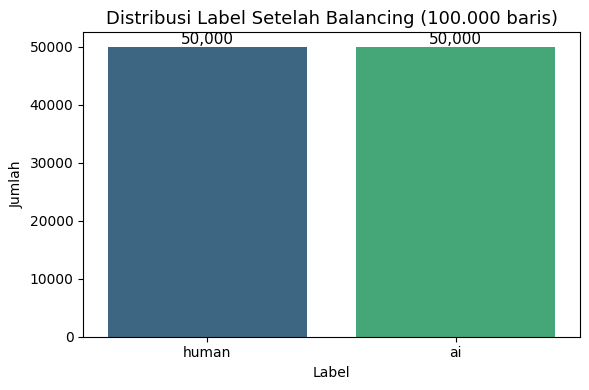

In [4]:
# ============================================================
# CELL 4: Visualisasi distribusi label setelah balancing
# ============================================================

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, x='source', hue='source',
    order=df['source'].value_counts().index,
    palette='viridis', legend=False
)
plt.title('Distribusi Label Setelah Balancing (100.000 baris)', fontsize=13)
plt.xlabel('Label'); plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Cell 5 — Feature Engineering Helper Functions

In [5]:
# ============================================================
# CELL 5: Definisi helper functions feature engineering
# Fitur: char_count, word_count, avg_word_length,
#        sentiment_score, subjectivity_score,
#        stopword_count, punctuation_count, upper_case_count
# ============================================================

STOP_WORDS  = set(stopwords.words('english'))
PUNCTUATION = set(string.punctuation)

def add_simple_features(df: pd.DataFrame) -> pd.DataFrame:
    """Fitur berbasis string (cepat, divektorisasi)."""
    df['char_count']        = df['text'].str.len()
    df['word_count']        = df['text'].apply(lambda x: len(x.split()))
    df['avg_word_length']   = (df['char_count'] /
                               df['word_count'].replace(0, np.nan)).fillna(0)
    df['punctuation_count'] = df['text'].apply(
        lambda x: sum(1 for ch in x if ch in PUNCTUATION))
    df['stopword_count']    = df['text'].apply(
        lambda x: sum(1 for w in x.lower().split() if w in STOP_WORDS))
    df['upper_case_count']  = df['text'].apply(
        lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
    return df

def _extract_textblob_row(text: str):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def add_textblob_features_mp(df: pd.DataFrame, n_jobs: int = None) -> pd.DataFrame:
    """Fitur TextBlob via multiprocessing."""
    n_jobs = n_jobs or max(1, cpu_count() - 1)
    with Pool(processes=n_jobs) as pool:
        results = pool.map(_extract_textblob_row, df['text'].tolist())
    pol, subj = zip(*results)
    df['sentiment_score']    = pol
    df['subjectivity_score'] = subj
    return df

print('✅ Helper functions berhasil didefinisikan.')

✅ Helper functions berhasil didefinisikan.


### Cell 6 — Jalankan Feature Engineering

In [6]:
# ============================================================
# CELL 6: Jalankan feature engineering pada 100.000 baris
# ============================================================

print('🔧 Feature Engineering dimulai...')
t0 = time.time()

print('  [1/2] Fitur string sederhana...')
df = add_simple_features(df)

print(f'  [2/2] TextBlob (multiprocessing, {max(1,cpu_count()-1)} proses)...')
df = add_textblob_features_mp(df)

print(f'\n✅ Selesai dalam {time.time()-t0:.1f} detik!')

🔧 Feature Engineering dimulai...
  [1/2] Fitur string sederhana...
  [2/2] TextBlob (multiprocessing, 1 proses)...

✅ Selesai dalam 237.5 detik!


### Cell 7 — Verifikasi & Statistik Fitur

In [7]:
# ============================================================
# CELL 7: Verifikasi hasil feature engineering
# ============================================================

print('📋 Info DataFrame:')
print(df.info())
print('\n🔍 Missing values:')
print(df.isnull().sum())
print('\n📊 Statistik deskriptif:')
df.describe().T

📋 Info DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   source              100000 non-null  object 
 1   text                100000 non-null  object 
 2   char_count          100000 non-null  int64  
 3   word_count          100000 non-null  int64  
 4   avg_word_length     100000 non-null  float64
 5   punctuation_count   100000 non-null  int64  
 6   stopword_count      100000 non-null  int64  
 7   upper_case_count    100000 non-null  int64  
 8   sentiment_score     100000 non-null  float64
 9   subjectivity_score  100000 non-null  float64
dtypes: float64(3), int64(5), object(2)
memory usage: 7.6+ MB
None

🔍 Missing values:
source                0
text                  0
char_count            0
word_count            0
avg_word_length       0
punctuation_count     0
stopword_count        0
upper_case_count  

,count,mean,std,min,25%,50%,75%,max
char_count,100000.0,2338.524460,3270.987654,0.0,979.000000,1124.000000,3489.000000,272770.0
word_count,100000.0,395.466110,483.293907,0.0,165.000000,203.000000,591.000000,25682.0
avg_word_length,100000.0,5.804813,4.876119,0.0,5.398907,5.712644,6.059585,963.0
punctuation_count,100000.0,70.389140,85.195005,0.0,24.000000,48.000000,99.000000,3532.0
stopword_count,100000.0,173.770760,203.624325,0.0,69.000000,97.000000,250.000000,11239.0
upper_case_count,100000.0,4.195950,11.138966,0.0,0.000000,1.000000,4.000000,557.0
sentiment_score,100000.0,0.098762,0.130093,-1.0,0.022975,0.092624,0.163452,1.0
subjectivity_score,100000.0,0.448260,0.122557,0.0,0.384936,0.451317,0.516667,1.0


### Cell 8 — Visualisasi Distribusi Fitur

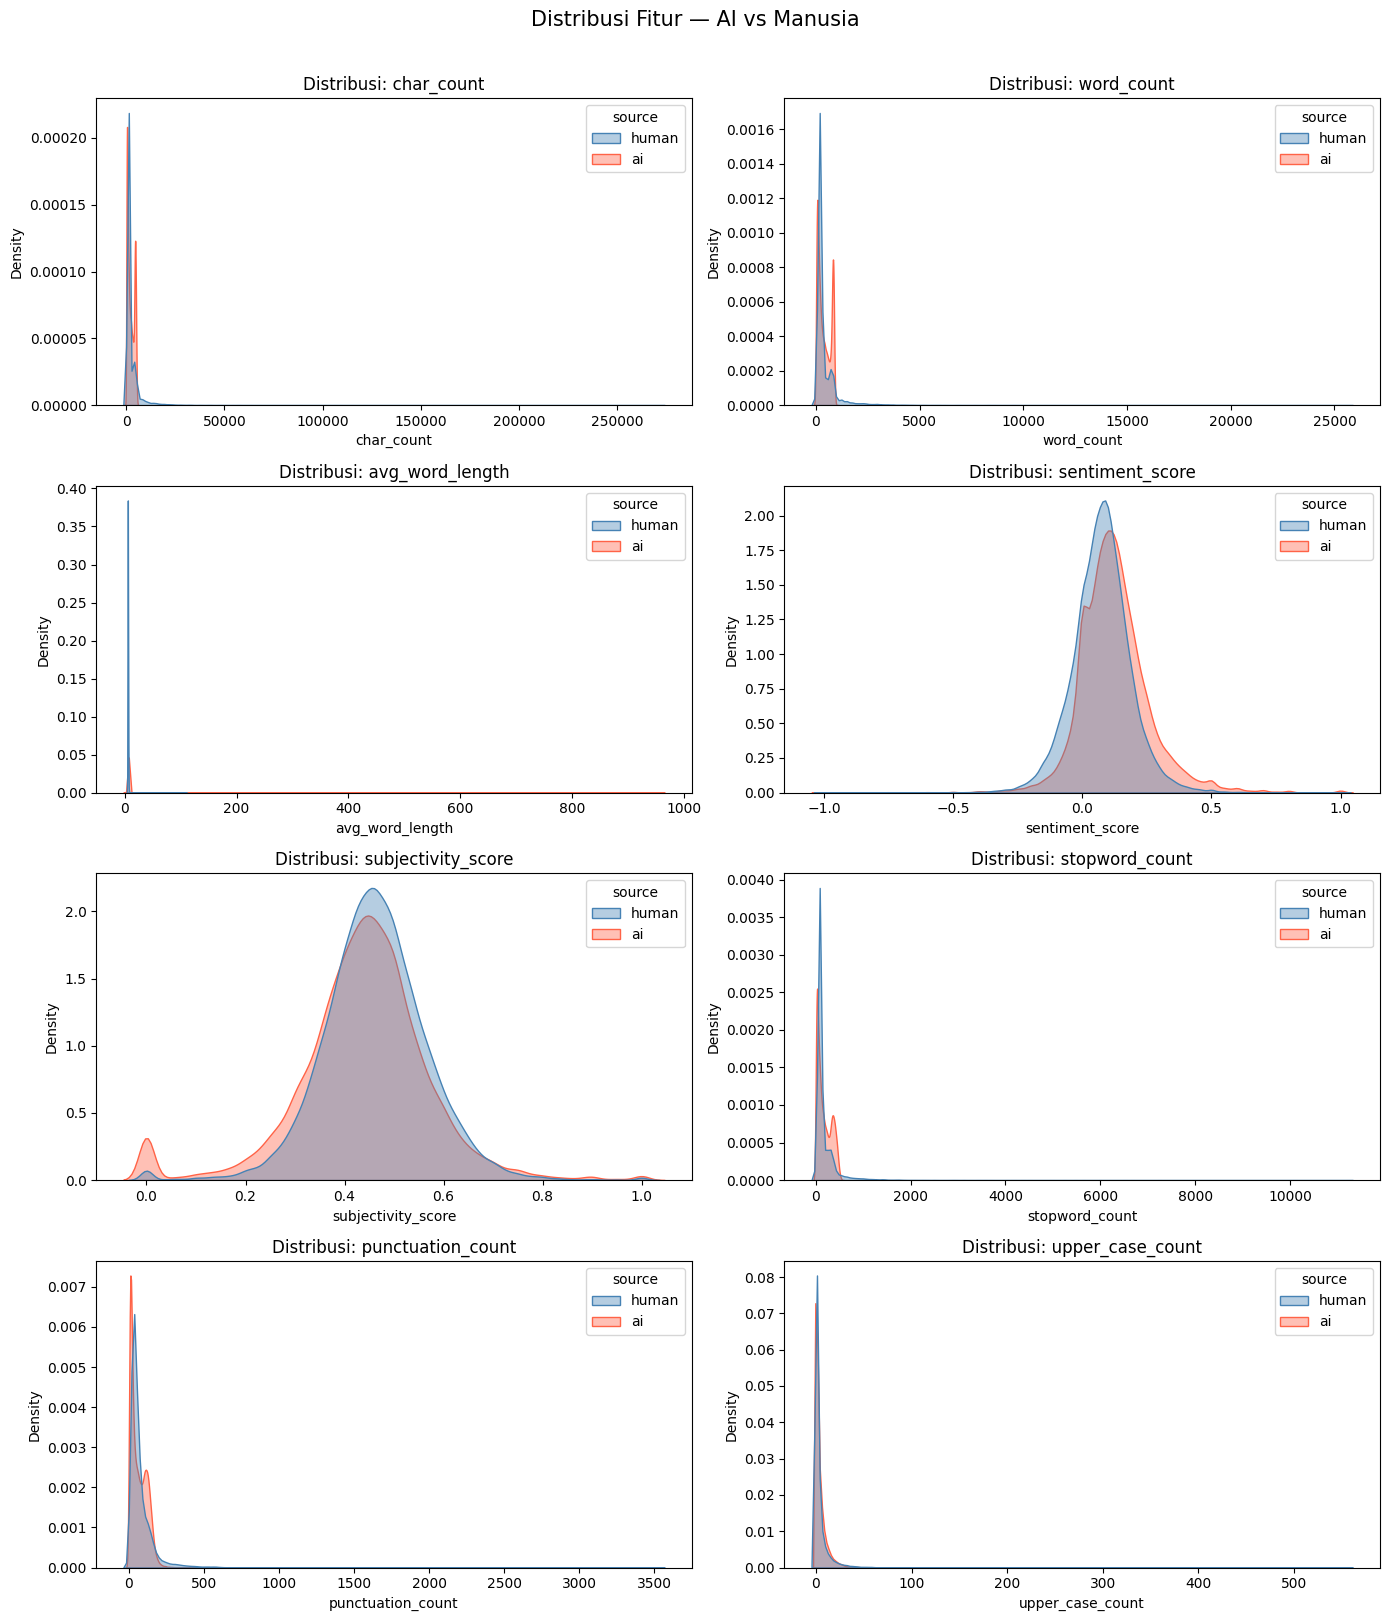

In [8]:
# ============================================================
# CELL 8: Plot distribusi 8 fitur per label
# ============================================================

FEATS = ['char_count','word_count','avg_word_length',
         'sentiment_score','subjectivity_score',
         'stopword_count','punctuation_count','upper_case_count']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, feat in zip(axes.flatten(), FEATS):
    sns.kdeplot(data=df, x=feat, hue='source', fill=True, alpha=0.4, ax=ax,
                palette={'human': 'steelblue', 'ai': 'tomato'})
    ax.set_title(f'Distribusi: {feat}', fontsize=12)
plt.suptitle('Distribusi Fitur — AI vs Manusia', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Cell 9 — Simpan CSV

In [9]:
# ============================================================
# CELL 9: Simpan DataFrame ke CSV
# ============================================================

CSV_PATH = 'ai_text_detection_features.csv'
df.to_csv(CSV_PATH, index=False)
print(f'💾 Disimpan ke {CSV_PATH}  ({len(df):,} baris × {len(df.columns)} kolom)')

💾 Disimpan ke ai_text_detection_features.csv  (100,000 baris × 10 kolom)


---
## ▶ BAGIAN II — Tokenisasi BERT

Model: **`bert-base-cased`**  
- Case-sensitive (cocok untuk teks campuran huruf besar/kecil)
- 12 transformer layers, 768 hidden units, 12 attention heads
- Tokenizer: WordPiece dengan vocab 28.996 token

### Cell 10 — Konfigurasi BERT & Sampling

In [10]:
# ============================================================
# CELL 10: Konfigurasi hyperparameter BERT
#
# BERT_SAMPLE_SIZE:
#   Untuk tes cepat pakai 10_000.
#   Untuk training penuh pakai 100_000 (butuh GPU berjam-jam).
#
# MAX_LENGTH:
#   128 = cukup untuk sebagian besar teks pendek-menengah.
#   256 = lebih akurat untuk teks panjang (RAM/VRAM lebih besar).
# ============================================================

MODEL_NAME      = 'bert-base-cased'
MAX_LENGTH      = 128        # panjang token maksimum per teks
BATCH_SIZE      = 8         # per-device batch size
NUM_EPOCHS      = 1
LEARNING_RATE   = 2e-5
WEIGHT_DECAY    = 0.01
BERT_SAMPLE_SIZE = 100_000   # ← ubah ke 100_000 untuk training penuh

print('🔧 Konfigurasi BERT:')
print(f'   Model          : {MODEL_NAME}')
print(f'   Max length     : {MAX_LENGTH}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Epochs         : {NUM_EPOCHS}')
print(f'   Learning rate  : {LEARNING_RATE}')
print(f'   Sample size    : {BERT_SAMPLE_SIZE:,} (dari 100.000 baris)')
print(f'   Device         : {DEVICE}')

🔧 Konfigurasi BERT:
   Model          : bert-base-cased
   Max length     : 128
   Batch size     : 8
   Epochs         : 1
   Learning rate  : 2e-05
   Sample size    : 100,000 (dari 100.000 baris)
   Device         : cuda


### Cell 11 — Encode Label & Sampling

In [11]:
# ============================================================
# CELL 11: Encode label dan ambil subset untuk training BERT
# ============================================================

# Encode label: 'ai' → 0, 'human' → 1
le = LabelEncoder()
df['label'] = le.fit_transform(df['source'])
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Ambil subset jika BERT_SAMPLE_SIZE < total data
if BERT_SAMPLE_SIZE < len(df):
    df_bert = (df.groupby('label', group_keys=False)
                 .apply(lambda x: x.sample(BERT_SAMPLE_SIZE // 2,
                                            random_state=RANDOM_SEED))
                 .reset_index(drop=True))
    print(f'\n⚡ Sample untuk BERT: {len(df_bert):,} baris')
else:
    df_bert = df.copy()
    print(f'\n📊 Menggunakan seluruh data: {len(df_bert):,} baris')

print(df_bert['source'].value_counts())

# Split 80/20 stratified
df_train, df_test = train_test_split(
    df_bert, test_size=0.20, random_state=RANDOM_SEED,
    stratify=df_bert['label']
)
print(f'\n   Train : {len(df_train):,} baris')
print(f'   Test  : {len(df_test):,} baris')

Label mapping: {'ai': np.int64(0), 'human': np.int64(1)}

📊 Menggunakan seluruh data: 100,000 baris
source
human    50000
ai       50000
Name: count, dtype: int64

   Train : 80,000 baris
   Test  : 20,000 baris


### Cell 12 — Tokenisasi dengan BertTokenizer

In [12]:
# ============================================================
# CELL 12: Tokenisasi teks menggunakan BertTokenizer
#
# WordPiece tokenizer dari bert-base-cased:
#   - Menghasilkan: input_ids, attention_mask, token_type_ids
#   - padding='max_length' → semua sekuens sama panjang
#   - truncation=True      → teks > MAX_LENGTH dipotong
# ============================================================

print(f'🔤 Memuat tokenizer {MODEL_NAME}...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(examples):
    """Tokenisasi satu batch teks."""
    return tokenizer(
        examples['text'],
        padding     = 'max_length',
        truncation  = True,
        max_length  = MAX_LENGTH
    )

# Buat HuggingFace Dataset dari pandas
hf_train = Dataset.from_pandas(df_train[['text', 'label']].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test[['text', 'label']].reset_index(drop=True))

print('🔤 Tokenisasi train set...')
t0 = time.time()
hf_train_tok = hf_train.map(tokenize_batch, batched=True, batch_size=512)
hf_test_tok  = hf_test.map(tokenize_batch,  batched=True, batch_size=512)

# Format untuk PyTorch
hf_train_tok.set_format('torch', columns=['input_ids','attention_mask','token_type_ids','label'])
hf_test_tok.set_format( 'torch', columns=['input_ids','attention_mask','token_type_ids','label'])

print(f'✅ Tokenisasi selesai dalam {time.time()-t0:.1f} detik.')
print(f'   Train tokens shape : {hf_train_tok.shape}')
print(f'   Test  tokens shape : {hf_test_tok.shape}')

# Contoh output tokenisasi
sample_tok = tokenizer(
    'This is an example of BERT tokenization.',
    return_tensors='pt'
)
print(f'\n🔍 Contoh token IDs : {sample_tok["input_ids"][0][:15].tolist()}...')
print(f'   Token strings     : {tokenizer.convert_ids_to_tokens(sample_tok["input_ids"][0][:15])}')

🔤 Memuat tokenizer bert-base-cased...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🔤 Tokenisasi train set...


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

✅ Tokenisasi selesai dalam 140.6 detik.
   Train tokens shape : (80000, 5)
   Test  tokens shape : (20000, 5)

🔍 Contoh token IDs : [101, 1188, 1110, 1126, 1859, 1104, 139, 9637, 1942, 22559, 2734, 119, 102]...
   Token strings     : ['[CLS]', 'This', 'is', 'an', 'example', 'of', 'B', '##ER', '##T', 'token', '##ization', '.', '[SEP]']


---
## ▶ BAGIAN III — Fine-tuning bert-base-cased

### Cell 13 — Inisialisasi Model & Compute Metrics

In [13]:
# ============================================================
# CELL 13: Inisialisasi BertForSequenceClassification
#
# - num_labels=2 (ai vs human)
# - model dipindah ke GPU jika tersedia
# - compute_metrics dipasang ke Trainer untuk monitoring live
# ============================================================

print(f'🤖 Memuat model {MODEL_NAME}...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = 2,
    id2label   = {0: le.classes_[0], 1: le.classes_[1]},
    label2id   = {le.classes_[0]: 0, le.classes_[1]: 1},
)
model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model dimuat. Total parameter : {total_params/1e6:.1f}M')

def compute_metrics(eval_pred):
    """Hitung accuracy dan F1 saat evaluasi tiap epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1'      : f1_score(labels, preds, average='weighted'),
    }

print('✅ compute_metrics didefinisikan.')

🤖 Memuat model bert-base-cased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model dimuat. Total parameter : 108.3M
✅ compute_metrics didefinisikan.


### Cell 14 — Training Arguments & Trainer

In [15]:
# ============================================================
# CELL 14: Perbaikan Konfigurasi TrainingArguments
# ============================================================

OUTPUT_DIR = './bert_output'
LOG_DIR    = './bert_logs'

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size  = BATCH_SIZE,
    per_device_eval_batch_size   = BATCH_SIZE * 2,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = 0.1,

    # --- PERBAIKAN DI SINI ---
    eval_strategy              = 'epoch', # Ganti dari evaluation_strategy
    save_strategy               = 'epoch',
    # -------------------------


    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    logging_dir                 = LOG_DIR,
    logging_steps               = 50,
    fp16                        = (DEVICE == 'cuda'),
    report_to                   = 'none',
    seed                        = RANDOM_SEED,
)

# Bagian Trainer dan seterusnya tetap sama
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = hf_train_tok,
    eval_dataset    = hf_test_tok,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Memulai fine-tuning BERT dengan 100k data...')
t0 = time.time()
trainer.train()
print(f'\n Selesai! Total waktu: {(time.time()-t0)/60:.1f} menit.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Memulai fine-tuning BERT dengan 100k data...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.094849,0.217086,0.953600,0.953526


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 Selesai! Total waktu: 16.2 menit.


---
## ▶ BAGIAN IV — Evaluasi

### Cell 15 — Classification Report & Confusion Matrix

📈 Evaluasi model pada test set...



  CLASSIFICATION REPORT — BERT (bert-base-cased)
              precision    recall  f1-score   support

          ai       0.92      0.99      0.96     10000
       human       0.99      0.91      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.95      0.95     20000

  ROC-AUC  : 0.9938


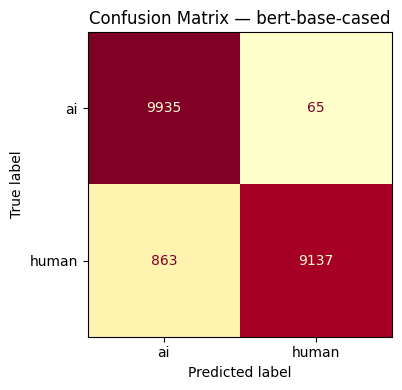

In [16]:
# ============================================================
# CELL 15: Prediksi dan evaluasi lengkap pada test set
# ============================================================

print('📈 Evaluasi model pada test set...')
predictions = trainer.predict(hf_test_tok)

logits     = predictions.predictions          # shape: (N, 2)
y_pred     = np.argmax(logits, axis=-1)
y_prob     = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
y_true     = predictions.label_ids

print('\n' + '='*55)
print('  CLASSIFICATION REPORT — BERT (bert-base-cased)')
print('='*55)
print(classification_report(y_true, y_pred, target_names=le.classes_))

auc_score = roc_auc_score(y_true, y_prob)
print(f'  ROC-AUC  : {auc_score:.4f}')

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='YlOrRd')
ax.set_title('Confusion Matrix — bert-base-cased')
plt.tight_layout()
plt.show()

### Cell 16 — ROC Curve

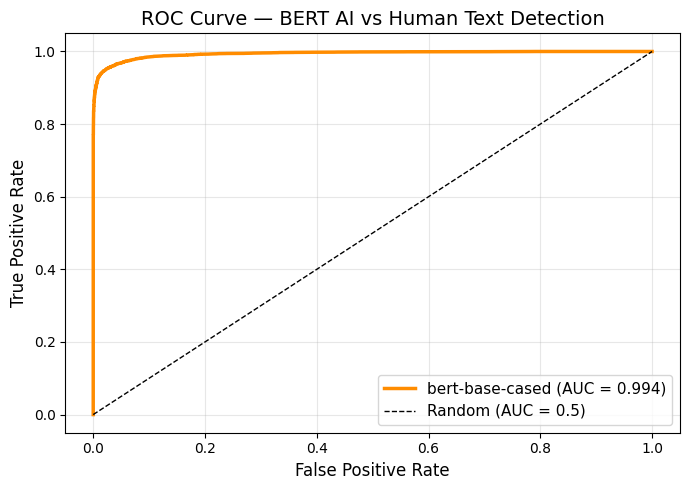


📊 Ringkasan Evaluasi BERT:
   Accuracy  : 0.9536
   F1 Score  : 0.9535
   ROC-AUC   : 0.9938


In [17]:
# ============================================================
# CELL 16: ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr,
         label=f'bert-base-cased (AUC = {auc_score:.3f})',
         color='darkorange', lw=2.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — BERT AI vs Human Text Detection', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Ringkasan
print(f'\n📊 Ringkasan Evaluasi BERT:')
print(f'   Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
print(f'   F1 Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
print(f'   ROC-AUC   : {auc_score:.4f}')

---
## ▶ BAGIAN V — Save Model & Tokenizer

### Cell 17 — Simpan Model & Tokenizer

In [18]:
# ============================================================
# CELL 17: Simpan model dan tokenizer menggunakan save_pretrained
#
# File yang dihasilkan di folder saved_bert_model/:
#   config.json          → konfigurasi arsitektur model
#   model.safetensors    → bobot model (format aman, lebih kecil)
#   tokenizer.json       → vocab dan aturan tokenisasi
#   tokenizer_config.json
#   vocab.txt            → vocabulary WordPiece
#   training_args.bin    → argumen training (untuk resume)
# ============================================================

SAVE_DIR = './saved_bert_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Simpan model terbaik dan tokenizer
trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Simpan label encoder dengan joblib
import joblib
joblib.dump(le, os.path.join(SAVE_DIR, 'label_encoder.pkl'))

print(f'💾 Model & tokenizer berhasil disimpan ke: {SAVE_DIR}/')
print('\n   File tersimpan:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f'   {f:<30} {size/1024:>8.1f} KB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model & tokenizer berhasil disimpan ke: ./saved_bert_model/

   File tersimpan:
   config.json                         0.9 KB
   label_encoder.pkl                   0.5 KB
   model.safetensors              423116.0 KB
   tokenizer.json                    653.2 KB
   tokenizer_config.json               0.3 KB


### Cell 18 — Demo Inferensi dari Model Tersimpan

In [19]:
# ============================================================
# CELL 18: Demo prediksi teks baru dari model file
#
# Alur inferensi:
#   teks → BertTokenizer → input_ids/attention_mask
#         → BertForSequenceClassification → logits → softmax → label
# ============================================================

# Muat ulang model dari file (simulasi environment baru)
loaded_model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_tok   = BertTokenizer.from_pretrained(SAVE_DIR)
loaded_le    = joblib.load(os.path.join(SAVE_DIR, 'label_encoder.pkl'))
loaded_model.to(DEVICE)
loaded_model.eval()

def predict_bert(text: str) -> str:
    """Prediksi single teks menggunakan model BERT tersimpan."""
    inputs = loaded_tok(
        text,
        return_tensors = 'pt',
        padding        = 'max_length',
        truncation     = True,
        max_length     = MAX_LENGTH
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = loaded_model(**inputs).logits
    proba = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred  = np.argmax(proba)
    label = loaded_le.inverse_transform([pred])[0]

    display = f'"{text[:110]}..."' if len(text) > 110 else f'"{text}"'
    print(f'Teks  : {display}')
    print(f'Hasil : {label.upper()}')
    for cls, p in zip(loaded_le.classes_, proba):
        bar = '█' * int(p * 30)
        print(f'  {cls:<8} {p*100:5.1f}%  {bar}')
    print()
    return label


print('=== DEMO INFERENSI BERT ===\n')

samples = [
    ('human',
     'I woke up at 6 am and rushed to the farmers market before '
     'the crowd arrived. The smell of fresh bread and herbs was wonderful.'),
    ('ai',
     'As an AI language model, I am designed to process and generate '
     'human-like text based on patterns learned from large corpora.'),
    ('custom',
     'Perkembangan kecerdasan buatan mengubah cara kita berinteraksi dengan '
     'teknologi secara fundamental di berbagai sektor industri global.'),
]

for expected, text in samples:
    print(f'[Expected: {expected}]')
    predict_bert(text)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== DEMO INFERENSI BERT ===

[Expected: human]
Teks  : "I woke up at 6 am and rushed to the farmers market before the crowd arrived. The smell of fresh bread and herb..."
Hasil : HUMAN
  ai         0.7%  
  human     99.3%  █████████████████████████████

[Expected: ai]
Teks  : "As an AI language model, I am designed to process and generate human-like text based on patterns learned from ..."
Hasil : AI
  ai        98.5%  █████████████████████████████
  human      1.5%  

[Expected: custom]
Teks  : "Perkembangan kecerdasan buatan mengubah cara kita berinteraksi dengan teknologi secara fundamental di berbagai..."
Hasil : HUMAN
  ai        43.3%  █████████████
  human     56.7%  ████████████████

